In [ ]:
# ============================================
# WASTE COLLECTION LIVE ETA SYSTEM
# Complete CoE Experiment Notebook
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# For reproducible results
np.random.seed(42)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# ============================================
# STEP 1: GENERATE SYNTHETIC DATA
# ============================================

N = 1000

customer_ids = [f"C{i:04d}" for i in range(1, N + 1)]

vehicle_ids = np.random.choice(
    ["V001", "V002", "V003", "V004", "V005"],
    N
)

route_ids = np.random.choice(
    ["R01", "R02", "R03", "R04", "R05",
     "R06", "R07", "R08", "R09", "R10"],
    N
)

# Distance between vehicle and customer
distance_km = np.round(
    np.random.uniform(0.5, 10.0, N),
    2
)

# Traffic level
traffic_levels = np.random.choice(
    ["Low", "Medium", "High"],
    N,
    p=[0.40, 0.40, 0.20]
)

# Traffic delay
traffic_delay = []

for traffic in traffic_levels:

    if traffic == "Low":
        delay = np.random.randint(0, 4)

    elif traffic == "Medium":
        delay = np.random.randint(4, 11)

    else:
        delay = np.random.randint(10, 31)

    traffic_delay.append(delay)

traffic_delay = np.array(traffic_delay)

# Expected collection/dwell time
expected_dwell = np.random.randint(
    3, 9, N
)

# Actual dwell time
actual_dwell = expected_dwell + np.random.randint(
    -1, 9, N
)

# Prevent negative values
actual_dwell = np.maximum(
    actual_dwell,
    2
)

# Approximate travel time
# Average speed assumed = 30 km/hour
base_travel_time = np.ceil(
    (distance_km / 30) * 60
).astype(int)

# Planned ETA
planned_eta = (
    base_travel_time
    + expected_dwell
)

# Extra operational delay
operational_delay = np.random.randint(
    0, 8, N
)

# Actual ETA
actual_eta = (
    base_travel_time
    + traffic_delay
    + actual_dwell
    + operational_delay
)

# Workload
workload_stops = np.random.randint(
    20, 61, N
)

# Maximum safe workload
max_workload = 50

# Customer time-window / commitment
time_windows = np.random.choice(
    ["Morning", "Afternoon", "Evening"],
    N
)

# Vehicle current location
current_locations = np.random.choice(
    ["Zone A", "Zone B", "Zone C",
     "Zone D", "Zone E"],
    N
)

# Route condition
route_conditions = np.random.choice(
    ["Normal", "Changed", "Blocked"],
    N,
    p=[0.80, 0.15, 0.05]
)

# Add route-related delay
route_delay = np.where(
    route_conditions == "Normal",
    0,
    np.where(
        route_conditions == "Changed",
        np.random.randint(3, 9, N),
        np.random.randint(8, 16, N)
    )
)

# Final actual ETA includes route condition
actual_eta = (
    actual_eta
    + route_delay
)

# Create DataFrame
df = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Vehicle_ID": vehicle_ids,
    "Route_ID": route_ids,
    "Current_Location": current_locations,
    "Distance_km": distance_km,
    "Traffic_Level": traffic_levels,
    "Traffic_Delay_min": traffic_delay,
    "Route_Condition": route_conditions,
    "Route_Delay_min": route_delay,
    "Expected_Dwell_min": expected_dwell,
    "Actual_Dwell_min": actual_dwell,
    "Planned_ETA_min": planned_eta,
    "Actual_ETA_min": actual_eta,
    "Workload_Stops": workload_stops,
    "Max_Workload": max_workload,
    "Customer_Time_Window": time_windows
})

print("✅ Dataset generated successfully!")
print("Number of records:", len(df))

display(df.head(10))

✅ Dataset generated successfully!
Number of records: 1000


,Customer_ID,Vehicle_ID,Route_ID,Current_Location,Distance_km,Traffic_Level,Traffic_Delay_min,Route_Condition,Route_Delay_min,Expected_Dwell_min,Actual_Dwell_min,Planned_ETA_min,Actual_ETA_min,Workload_Stops,Max_Workload,Customer_Time_Window
0,C0001,V004,R04,Zone D,4.74,Medium,8,Changed,3,7,9,17,37,58,50,Morning
1,C0002,V005,R04,Zone B,7.38,Low,0,Normal,0,3,8,18,24,55,50,Morning
2,C0003,V003,R05,Zone E,0.65,Low,0,Changed,7,3,10,5,24,49,50,Afternoon
3,C0004,V005,R08,Zone A,3.74,Low,0,Normal,0,4,7,12,21,42,50,Evening
4,C0005,V005,R05,Zone A,8.28,Medium,8,Normal,0,7,7,24,33,38,50,Evening
5,C0006,V002,R08,Zone A,6.23,Low,1,Normal,0,6,11,19,25,31,50,Afternoon
6,C0007,V003,R10,Zone A,3.70,High,28,Normal,0,8,16,16,56,34,50,Afternoon
7,C0008,V003,R01,Zone B,9.10,Medium,8,Normal,0,7,6,26,40,50,50,Evening
8,C0009,V003,R10,Zone C,7.84,Medium,4,Normal,0,5,10,21,30,56,50,Evening
9,C0010,V005,R09,Zone D,3.02,Low,3,Changed,7,3,7,10,30,56,50,Afternoon


In [ ]:
# ============================================
# STEP 2: DATASET INFORMATION
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(1000, 16)

Column Names:
['Customer_ID', 'Vehicle_ID', 'Route_ID', 'Current_Location', 'Distance_km', 'Traffic_Level', 'Traffic_Delay_min', 'Route_Condition', 'Route_Delay_min', 'Expected_Dwell_min', 'Actual_Dwell_min', 'Planned_ETA_min', 'Actual_ETA_min', 'Workload_Stops', 'Max_Workload', 'Customer_Time_Window']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           1000 non-null   object 
 1   Vehicle_ID            1000 non-null   object 
 2   Route_ID              1000 non-null   object 
 3   Current_Location      1000 non-null   object 
 4   Distance_km           1000 non-null   float64
 5   Traffic_Level         1000 non-null   object 
 6   Traffic_Delay_min     1000 non-null   int64  
 7   Route_Condition       1000 non-null   object 
 8   Route_Delay_min       1000

In [ ]:
# ============================================

# STEP 3: CHECK MISSING VALUES

# ============================================

missing_values = df.isnull().sum()

print("Missing values in each column:")

print(missing_values)

if missing_values.sum() == 0:

    print("\n✅ No missing values found!")

else:

    print("\n⚠️ Missing values detected.")

Missing values in each column:
Customer_ID             0
Vehicle_ID              0
Route_ID                0
Current_Location        0
Distance_km             0
Traffic_Level           0
Traffic_Delay_min       0
Route_Condition         0
Route_Delay_min         0
Expected_Dwell_min      0
Actual_Dwell_min        0
Planned_ETA_min         0
Actual_ETA_min          0
Workload_Stops          0
Max_Workload            0
Customer_Time_Window    0
dtype: int64

✅ No missing values found!


In [ ]:
# ============================================
# STEP 4: CHECK DUPLICATES
# ============================================

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

if duplicates == 0:
    print("✅ No duplicate records found!")
else:
    print("⚠️ Duplicate records found.")

    df = df.drop_duplicates()

print("Dataset size after duplicate removal:", len(df))

Number of duplicate records: 0
✅ No duplicate records found!
Dataset size after duplicate removal: 1000


In [ ]:
# ============================================
# STEP 5: BASIC STATISTICS
# ============================================

display(
    df.describe()
)

,Distance_km,Traffic_Delay_min,Route_Delay_min,Expected_Dwell_min,Actual_Dwell_min,Planned_ETA_min,Actual_ETA_min,Workload_Stops,Max_Workload
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,5.171260,7.750000,1.2970,5.515000,9.078000,16.356000,32.318000,40.010000,50.0
std,2.757221,7.246932,3.0013,1.720679,3.352485,5.783313,10.758467,11.824031,0.0
min,0.500000,0.000000,0.0000,3.000000,2.000000,5.000000,7.000000,20.000000,50.0
25%,2.710000,2.000000,0.0000,4.000000,7.000000,12.000000,24.000000,30.000000,50.0
50%,5.170000,6.000000,0.0000,5.000000,9.000000,16.000000,31.000000,40.000000,50.0
75%,7.567500,10.000000,0.0000,7.000000,11.000000,21.000000,39.000000,50.000000,50.0
max,10.000000,30.000000,15.0000,8.000000,16.000000,28.000000,75.000000,60.000000,50.0


Traffic Level Distribution:
Traffic_Level
Medium    436
Low       357
High      207
Name: count, dtype: int64


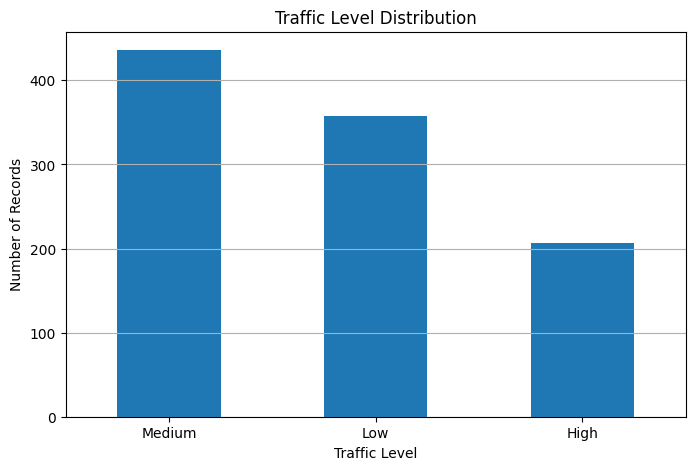

In [ ]:
# ============================================
# STEP 6: TRAFFIC DISTRIBUTION
# ============================================

print("Traffic Level Distribution:")
print(df["Traffic_Level"].value_counts())

plt.figure(figsize=(8, 5))

df["Traffic_Level"].value_counts().plot(
    kind="bar"
)

plt.title("Traffic Level Distribution")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [ ]:
# ============================================
# STEP 7: WORKLOAD ANALYSIS
# ============================================

safe_count = (
    df["Workload_Stops"] <= df["Max_Workload"]
).sum()

overloaded_count = (
    df["Workload_Stops"] > df["Max_Workload"]
).sum()

print("Safe workload records:", safe_count)
print("Overloaded records:", overloaded_count)

df["Workload_Status"] = np.where(
    df["Workload_Stops"] <= df["Max_Workload"],
    "SAFE",
    "OVERLOADED"
)

display(
    df[
        [
            "Vehicle_ID",
            "Workload_Stops",
            "Max_Workload",
            "Workload_Status"
        ]
    ].head(20)
)

Safe workload records: 753
Overloaded records: 247


,Vehicle_ID,Workload_Stops,Max_Workload,Workload_Status
0,V004,58,50,OVERLOADED
1,V005,55,50,OVERLOADED
2,V003,49,50,SAFE
3,V005,42,50,SAFE
4,V005,38,50,SAFE
5,V002,31,50,SAFE
6,V003,34,50,SAFE
7,V003,50,50,SAFE
8,V003,56,50,OVERLOADED
9,V005,56,50,OVERLOADED


In [ ]:
# ============================================
# STEP 8: BASELINE ETA
# ============================================

# Baseline only trusts the original planned ETA

df["Baseline_ETA"] = df["Planned_ETA_min"]

print("✅ Baseline ETA created!")

display(
    df[
        [
            "Customer_ID",
            "Planned_ETA_min",
            "Baseline_ETA",
            "Actual_ETA_min"
        ]
    ].head(10)
)

✅ Baseline ETA created!


,Customer_ID,Planned_ETA_min,Baseline_ETA,Actual_ETA_min
0,C0001,17,17,37
1,C0002,18,18,24
2,C0003,5,5,24
3,C0004,12,12,21
4,C0005,24,24,33
5,C0006,19,19,25
6,C0007,16,16,56
7,C0008,26,26,40
8,C0009,21,21,30
9,C0010,10,10,30


In [ ]:
# ============================================
# STEP 9: DYNAMIC ETA
# ============================================

# Difference between actual and expected dwell time
df["Dwell_Delay_min"] = (
    df["Actual_Dwell_min"]
    - df["Expected_Dwell_min"]
)

# Dynamic ETA
df["Dynamic_ETA"] = (
    df["Planned_ETA_min"]
    + df["Traffic_Delay_min"]
    + df["Dwell_Delay_min"]
    + df["Route_Delay_min"]
)

print("✅ Dynamic ETA calculated!")

display(
    df[
        [
            "Customer_ID",
            "Baseline_ETA",
            "Traffic_Delay_min",
            "Dwell_Delay_min",
            "Route_Delay_min",
            "Dynamic_ETA",
            "Actual_ETA_min"
        ]
    ].head(10)
)

✅ Dynamic ETA calculated!


,Customer_ID,Baseline_ETA,Traffic_Delay_min,Dwell_Delay_min,Route_Delay_min,Dynamic_ETA,Actual_ETA_min
0,C0001,17,8,2,3,30,37
1,C0002,18,0,5,0,23,24
2,C0003,5,0,7,7,19,24
3,C0004,12,0,3,0,15,21
4,C0005,24,8,0,0,32,33
5,C0006,19,1,5,0,25,25
6,C0007,16,28,8,0,52,56
7,C0008,26,8,-1,0,33,40
8,C0009,21,4,5,0,30,30
9,C0010,10,3,4,7,24,30


In [ ]:
# ============================================
# STEP 10: ETA ERROR
# ============================================

df["Baseline_Error"] = abs(
    df["Baseline_ETA"]
    - df["Actual_ETA_min"]
)

df["Dynamic_Error"] = abs(
    df["Dynamic_ETA"]
    - df["Actual_ETA_min"]
)

display(
    df[
        [
            "Customer_ID",
            "Baseline_ETA",
            "Dynamic_ETA",
            "Actual_ETA_min",
            "Baseline_Error",
            "Dynamic_Error"
        ]
    ].head(20)
)

,Customer_ID,Baseline_ETA,Dynamic_ETA,Actual_ETA_min,Baseline_Error,Dynamic_Error
0,C0001,17,30,37,20,7
1,C0002,18,23,24,6,1
2,C0003,5,19,24,19,5
3,C0004,12,15,21,9,6
4,C0005,24,32,33,9,1
5,C0006,19,25,25,6,0
6,C0007,16,52,56,40,4
7,C0008,26,33,40,14,7
8,C0009,21,30,30,9,0
9,C0010,10,24,30,20,6


In [ ]:
# ============================================
# STEP 11: MEAN ABSOLUTE ERROR
# ============================================

baseline_mae = df["Baseline_Error"].mean()

dynamic_mae = df["Dynamic_Error"].mean()

print(
    "Baseline MAE:",
    round(baseline_mae, 2),
    "minutes"
)

print(
    "Dynamic ETA MAE:",
    round(dynamic_mae, 2),
    "minutes"
)

if dynamic_mae < baseline_mae:
    print("\n✅ Dynamic ETA performs better than baseline.")
else:
    print("\n⚠️ Dynamic ETA needs improvement.")

Baseline MAE: 15.96 minutes
Dynamic ETA MAE: 3.35 minutes

✅ Dynamic ETA performs better than baseline.


In [ ]:
# ============================================
# STEP 12: RMSE
# ============================================

baseline_rmse = np.sqrt(
    np.mean(
        (df["Baseline_ETA"] - df["Actual_ETA_min"]) ** 2
    )
)

dynamic_rmse = np.sqrt(
    np.mean(
        (df["Dynamic_ETA"] - df["Actual_ETA_min"]) ** 2
    )
)

print(
    "Baseline RMSE:",
    round(baseline_rmse, 2),
    "minutes"
)

print(
    "Dynamic ETA RMSE:",
    round(dynamic_rmse, 2),
    "minutes"
)

Baseline RMSE: 18.18 minutes
Dynamic ETA RMSE: 4.08 minutes


In [ ]:
# ============================================
# STEP 13: ETA ERROR IMPROVEMENT
# ============================================

if baseline_mae != 0:

    mae_improvement = (
        (baseline_mae - dynamic_mae)
        / baseline_mae
    ) * 100

else:
    mae_improvement = 0

print(
    "ETA Error Improvement:",
    round(mae_improvement, 2),
    "%"
)

ETA Error Improvement: 79.0 %


In [ ]:
# ============================================
# STEP 14: ACCURACY WITHIN 5 MINUTES
# ============================================

baseline_5min_accuracy = (
    df["Baseline_Error"] <= 5
).mean() * 100

dynamic_5min_accuracy = (
    df["Dynamic_Error"] <= 5
).mean() * 100

print(
    "Baseline accuracy within 5 minutes:",
    round(baseline_5min_accuracy, 2),
    "%"
)

print(
    "Dynamic ETA accuracy within 5 minutes:",
    round(dynamic_5min_accuracy, 2),
    "%"
)

Baseline accuracy within 5 minutes: 7.3 %
Dynamic ETA accuracy within 5 minutes: 76.3 %


In [ ]:
# ============================================
# STEP 15: ACCURACY WITHIN 10 MINUTES
# ============================================

baseline_10min_accuracy = (
    df["Baseline_Error"] <= 10
).mean() * 100

dynamic_10min_accuracy = (
    df["Dynamic_Error"] <= 10
).mean() * 100

print(
    "Baseline accuracy within 10 minutes:",
    round(baseline_10min_accuracy, 2),
    "%"
)

print(
    "Dynamic ETA accuracy within 10 minutes:",
    round(dynamic_10min_accuracy, 2),
    "%"
)

Baseline accuracy within 10 minutes: 29.3 %
Dynamic ETA accuracy within 10 minutes: 100.0 %


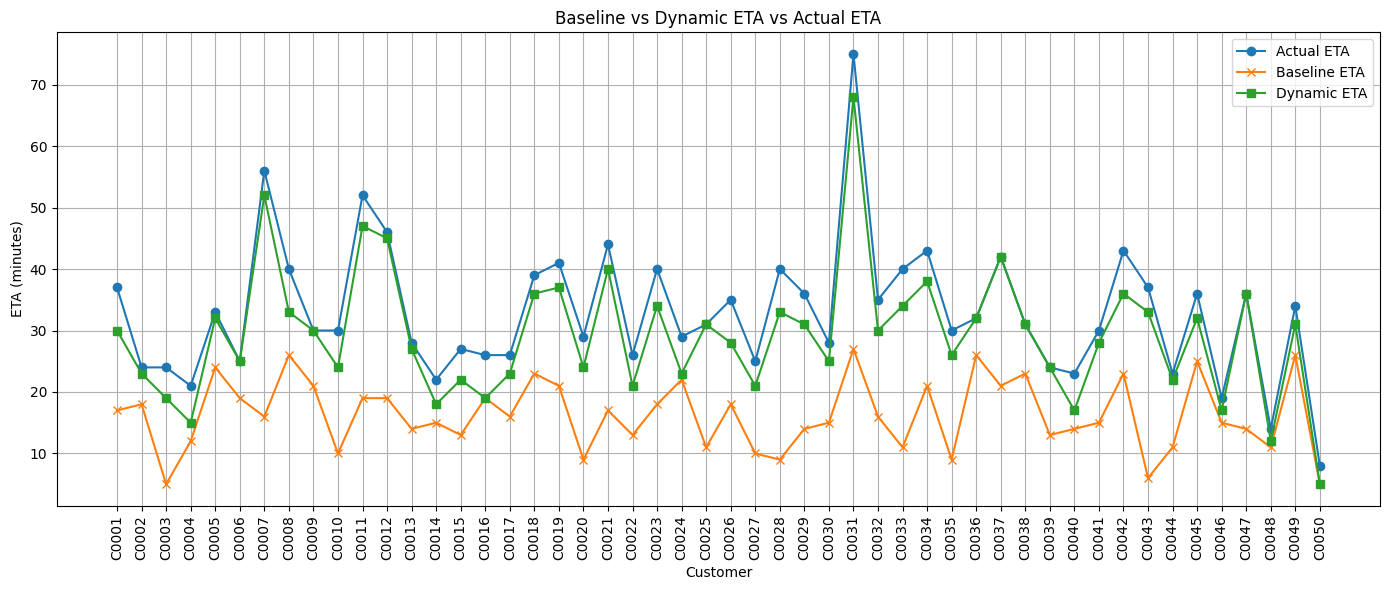

In [ ]:
# ============================================
# STEP 16: ETA COMPARISON GRAPH
# ============================================

# Use first 50 records for readability

sample = df.head(50)

plt.figure(figsize=(14, 6))

plt.plot(
    sample["Customer_ID"],
    sample["Actual_ETA_min"],
    marker="o",
    label="Actual ETA"
)

plt.plot(
    sample["Customer_ID"],
    sample["Baseline_ETA"],
    marker="x",
    label="Baseline ETA"
)

plt.plot(
    sample["Customer_ID"],
    sample["Dynamic_ETA"],
    marker="s",
    label="Dynamic ETA"
)

plt.title(
    "Baseline vs Dynamic ETA vs Actual ETA"
)

plt.xlabel("Customer")
plt.ylabel("ETA (minutes)")

plt.xticks(rotation=90)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

,System,MAE,RMSE
0,Baseline,15.964,18.184609
1,Dynamic ETA,3.352,4.077254


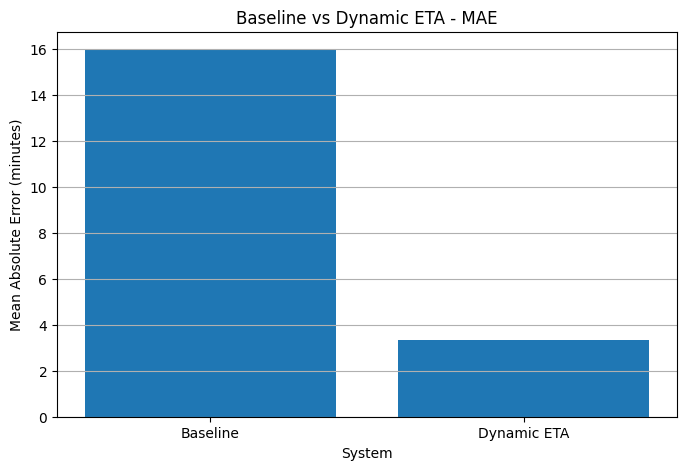

In [ ]:
# ============================================
# STEP 17: ERROR COMPARISON
# ============================================

comparison = pd.DataFrame({
    "System": [
        "Baseline",
        "Dynamic ETA"
    ],

    "MAE": [
        baseline_mae,
        dynamic_mae
    ],

    "RMSE": [
        baseline_rmse,
        dynamic_rmse
    ]
})

display(comparison)

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["System"],
    comparison["MAE"]
)

plt.title("Baseline vs Dynamic ETA - MAE")

plt.xlabel("System")

plt.ylabel("Mean Absolute Error (minutes)")

plt.grid(axis="y")

plt.show()

In [ ]:
# ============================================
# STEP 18: FAILURE CASE 1
# HEAVY TRAFFIC
# ============================================

traffic_test = df.copy()

customer = "C0001"

old_delay = traffic_test.loc[
    traffic_test["Customer_ID"] == customer,
    "Traffic_Delay_min"
].iloc[0]

traffic_test.loc[
    traffic_test["Customer_ID"] == customer,
    "Traffic_Delay_min"
] = 30

traffic_test.loc[
    traffic_test["Customer_ID"] == customer,
    "Dynamic_ETA"
] = (
    traffic_test.loc[
        traffic_test["Customer_ID"] == customer,
        "Planned_ETA_min"
    ].iloc[0]
    + 30
    + traffic_test.loc[
        traffic_test["Customer_ID"] == customer,
        "Dwell_Delay_min"
    ].iloc[0]
    + traffic_test.loc[
        traffic_test["Customer_ID"] == customer,
        "Route_Delay_min"
    ].iloc[0]
)

result = traffic_test[
    traffic_test["Customer_ID"] == customer
]

print("🚦 HEAVY TRAFFIC TEST")

display(
    result[
        [
            "Customer_ID",
            "Traffic_Level",
            "Traffic_Delay_min",
            "Baseline_ETA",
            "Dynamic_ETA"
        ]
    ]
)

🚦 HEAVY TRAFFIC TEST


,Customer_ID,Traffic_Level,Traffic_Delay_min,Baseline_ETA,Dynamic_ETA
0,C0001,Medium,30,17,52


In [ ]:
# ============================================
# STEP 19: FAILURE CASE 2
# LONG COLLECTION TIME
# ============================================

dwell_test = df.copy()

customer = "C0002"

dwell_test.loc[
    dwell_test["Customer_ID"] == customer,
    "Actual_Dwell_min"
] = 25

dwell_test.loc[
    dwell_test["Customer_ID"] == customer,
    "Dwell_Delay_min"
] = (
    dwell_test.loc[
        dwell_test["Customer_ID"] == customer,
        "Actual_Dwell_min"
    ].iloc[0]
    -
    dwell_test.loc[
        dwell_test["Customer_ID"] == customer,
        "Expected_Dwell_min"
    ].iloc[0]
)

dwell_test.loc[
    dwell_test["Customer_ID"] == customer,
    "Dynamic_ETA"
] = (
    dwell_test.loc[
        dwell_test["Customer_ID"] == customer,
        "Planned_ETA_min"
    ].iloc[0]
    +
    dwell_test.loc[
        dwell_test["Customer_ID"] == customer,
        "Traffic_Delay_min"
    ].iloc[0]
    +
    dwell_test.loc[
        dwell_test["Customer_ID"] == customer,
        "Dwell_Delay_min"
    ].iloc[0]
    +
    dwell_test.loc[
        dwell_test["Customer_ID"] == customer,
        "Route_Delay_min"
    ].iloc[0]
)

print("🗑️ LONG COLLECTION TIME TEST")

display(
    dwell_test[
        dwell_test["Customer_ID"] == customer
    ][
        [
            "Customer_ID",
            "Expected_Dwell_min",
            "Actual_Dwell_min",
            "Dwell_Delay_min",
            "Dynamic_ETA"
        ]
    ]
)

🗑️ LONG COLLECTION TIME TEST


,Customer_ID,Expected_Dwell_min,Actual_Dwell_min,Dwell_Delay_min,Dynamic_ETA
1,C0002,3,25,22,40


In [ ]:
# ============================================
# STEP 20: FAILURE CASE 3
# ROUTE CHANGE
# ============================================

route_test = df.copy()

customer = "C0003"

route_test.loc[
    route_test["Customer_ID"] == customer,
    "Route_Condition"
] = "Changed"

route_test.loc[
    route_test["Customer_ID"] == customer,
    "Route_Delay_min"
] = 10

route_test.loc[
    route_test["Customer_ID"] == customer,
    "Dynamic_ETA"
] = (
    route_test.loc[
        route_test["Customer_ID"] == customer,
        "Planned_ETA_min"
    ].iloc[0]
    +
    route_test.loc[
        route_test["Customer_ID"] == customer,
        "Traffic_Delay_min"
    ].iloc[0]
    +
    route_test.loc[
        route_test["Customer_ID"] == customer,
        "Dwell_Delay_min"
    ].iloc[0]
    + 10
)

print("🗺️ ROUTE CHANGE TEST")

display(
    route_test[
        route_test["Customer_ID"] == customer
    ][
        [
            "Customer_ID",
            "Route_ID",
            "Route_Condition",
            "Route_Delay_min",
            "Baseline_ETA",
            "Dynamic_ETA"
        ]
    ]
)

🗺️ ROUTE CHANGE TEST


,Customer_ID,Route_ID,Route_Condition,Route_Delay_min,Baseline_ETA,Dynamic_ETA
2,C0003,R05,Changed,10,5,22


In [ ]:
# ============================================
# STEP 21: FAILURE CASE 4
# WORKER / VEHICLE OVERLOAD
# ============================================

workload_test = df.copy()

customer = "C0004"

workload_test.loc[
    workload_test["Customer_ID"] == customer,
    "Workload_Stops"
] = 65

workload_test.loc[
    workload_test["Customer_ID"] == customer,
    "Workload_Status"
] = np.where(
    workload_test.loc[
        workload_test["Customer_ID"] == customer,
        "Workload_Stops"
    ].iloc[0]
    <=
    workload_test.loc[
        workload_test["Customer_ID"] == customer,
        "Max_Workload"
    ].iloc[0],
    "SAFE",
    "OVERLOADED"
)

print("👷 WORKLOAD SAFETY TEST")

display(
    workload_test[
        workload_test["Customer_ID"] == customer
    ][
        [
            "Customer_ID",
            "Workload_Stops",
            "Max_Workload",
            "Workload_Status"
        ]
    ]
)

👷 WORKLOAD SAFETY TEST


,Customer_ID,Workload_Stops,Max_Workload,Workload_Status
3,C0004,65,50,OVERLOADED


In [ ]:
# ============================================
# STEP 22: CUSTOMER NOTIFICATION
# ============================================

def generate_notification(row):

    delay = (
        row["Dynamic_ETA"]
        - row["Baseline_ETA"]
    )

    if delay >= 15:

        return (
            f"🚨 Major delay: Your waste collection "
            f"ETA has increased by {int(delay)} minutes."
        )

    elif delay >= 5:

        return (
            f"⚠️ Delay update: Your waste collection "
            f"ETA has increased by {int(delay)} minutes."
        )

    elif delay > 0:

        return (
            f"ℹ️ ETA updated by {int(delay)} minutes."
        )

    else:

        return (
            "✅ Your waste collection is on schedule."
        )


df["Customer_Notification"] = df.apply(
    generate_notification,
    axis=1
)

display(
    df[
        [
            "Customer_ID",
            "Baseline_ETA",
            "Dynamic_ETA",
            "Customer_Notification"
        ]
    ].head(20)
)

,Customer_ID,Baseline_ETA,Dynamic_ETA,Customer_Notification
0,C0001,17,30,⚠️ Delay update: Your waste collection ETA has...
1,C0002,18,23,⚠️ Delay update: Your waste collection ETA has...
2,C0003,5,19,⚠️ Delay update: Your waste collection ETA has...
3,C0004,12,15,ℹ️ ETA updated by 3 minutes.
4,C0005,24,32,⚠️ Delay update: Your waste collection ETA has...
5,C0006,19,25,⚠️ Delay update: Your waste collection ETA has...
6,C0007,16,52,🚨 Major delay: Your waste collection ETA has i...
7,C0008,26,33,⚠️ Delay update: Your waste collection ETA has...
8,C0009,21,30,⚠️ Delay update: Your waste collection ETA has...
9,C0010,10,24,⚠️ Delay update: Your waste collection ETA has...


In [ ]:
# ============================================
# STEP 23: CUSTOMER STATUS ENQUIRIES
# ============================================

# Customers with a delay greater than 10 minutes
# are more likely to make a status enquiry.

df["Baseline_Status_Enquiry"] = np.where(
    df["Baseline_Error"] > 10,
    1,
    0
)

df["Dynamic_Status_Enquiry"] = np.where(
    df["Dynamic_Error"] > 10,
    1,
    0
)

baseline_enquiries = (
    df["Baseline_Status_Enquiry"].sum()
)

dynamic_enquiries = (
    df["Dynamic_Status_Enquiry"].sum()
)

print(
    "Baseline status enquiries:",
    baseline_enquiries
)

print(
    "Dynamic ETA status enquiries:",
    dynamic_enquiries
)

if baseline_enquiries > 0:

    enquiry_reduction = (
        (baseline_enquiries - dynamic_enquiries)
        / baseline_enquiries
    ) * 100

else:

    enquiry_reduction = 0

print(
    "Status enquiry reduction:",
    round(enquiry_reduction, 2),
    "%"
)

Baseline status enquiries: 707
Dynamic ETA status enquiries: 0
Status enquiry reduction: 100.0 %


,System,Status_Enquiries
0,Baseline,707
1,Dynamic ETA,0


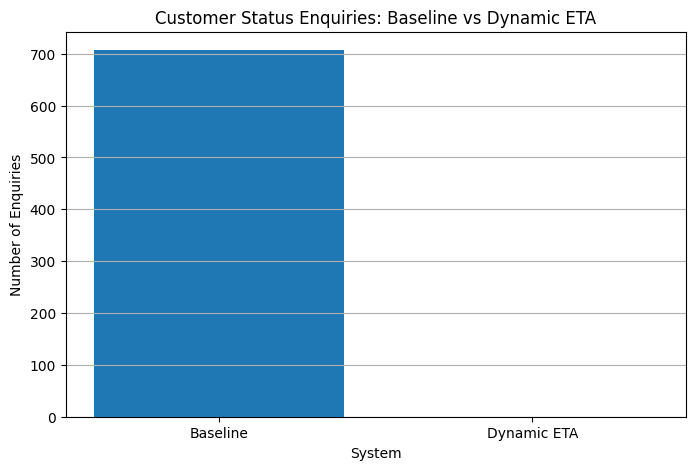

In [ ]:
# ============================================
# STEP 24: CUSTOMER ENQUIRY COMPARISON
# ============================================

enquiry_data = pd.DataFrame({
    "System": [
        "Baseline",
        "Dynamic ETA"
    ],

    "Status_Enquiries": [
        baseline_enquiries,
        dynamic_enquiries
    ]
})

display(enquiry_data)

plt.figure(figsize=(8, 5))

plt.bar(
    enquiry_data["System"],
    enquiry_data["Status_Enquiries"]
)

plt.title(
    "Customer Status Enquiries: Baseline vs Dynamic ETA"
)

plt.xlabel("System")

plt.ylabel("Number of Enquiries")

plt.grid(axis="y")

plt.show()

In [ ]:
# ============================================
# STEP 25: ERROR ANALYSIS
# ============================================

df["Main_Error_Cause"] = np.select(

    [
        df["Traffic_Delay_min"] >= 15,

        df["Route_Delay_min"] >= 8,

        df["Dwell_Delay_min"] >= 5,

        df["Baseline_Error"] > 10
    ],

    [
        "Heavy Traffic",

        "Route Change / Blockage",

        "Long Collection Time",

        "Other Operational Delay"
    ],

    default="Normal"
)

print("Main error causes:")

display(
    df["Main_Error_Cause"]
    .value_counts()
    .to_frame("Count")
)

Main error causes:


,Count
Main_Error_Cause,
Long Collection Time,328
Normal,242
Other Operational Delay,218
Heavy Traffic,158
Route Change / Blockage,54


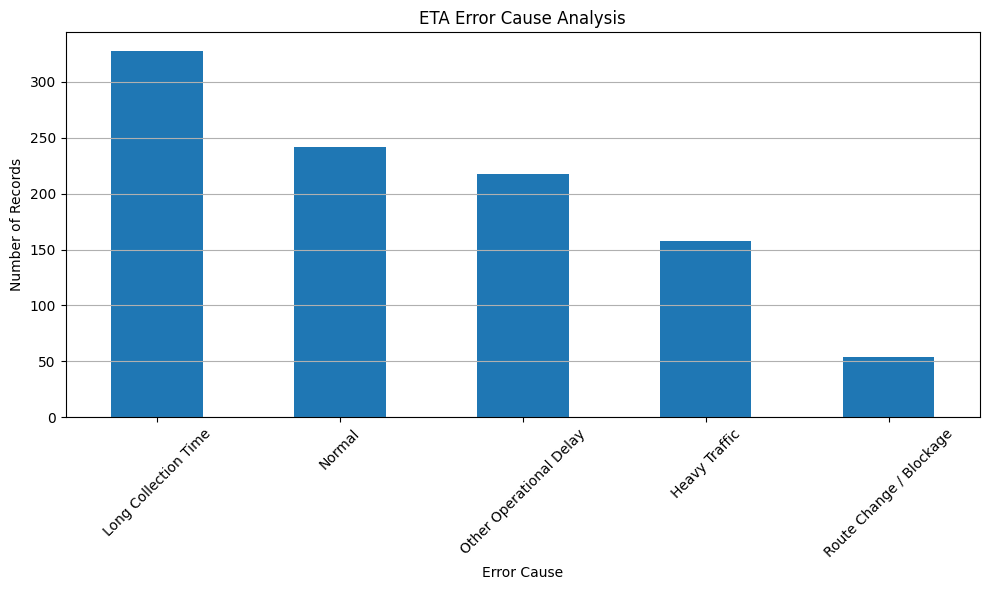

In [ ]:
# ============================================
# STEP 26: ERROR CAUSE GRAPH
# ============================================

error_counts = (
    df["Main_Error_Cause"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

error_counts.plot(
    kind="bar"
)

plt.title("ETA Error Cause Analysis")

plt.xlabel("Error Cause")

plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# STEP 27: FINAL EVALUATION
# ============================================

final_results = pd.DataFrame({

    "Metric": [

        "Baseline MAE",

        "Dynamic ETA MAE",

        "Baseline RMSE",

        "Dynamic ETA RMSE",

        "Baseline Accuracy within 5 min",

        "Dynamic Accuracy within 5 min",

        "Baseline Accuracy within 10 min",

        "Dynamic Accuracy within 10 min",

        "ETA Error Improvement",

        "Customer Enquiry Reduction"

    ],

    "Value": [

        round(baseline_mae, 2),

        round(dynamic_mae, 2),

        round(baseline_rmse, 2),

        round(dynamic_rmse, 2),

        round(baseline_5min_accuracy, 2),

        round(dynamic_5min_accuracy, 2),

        round(baseline_10min_accuracy, 2),

        round(dynamic_10min_accuracy, 2),

        round(mae_improvement, 2),

        round(enquiry_reduction, 2)

    ],

    "Unit": [

        "minutes",

        "minutes",

        "minutes",

        "minutes",

        "%",

        "%",

        "%",

        "%",

        "%",

        "%"

    ]
})

display(final_results)

,Metric,Value,Unit
0,Baseline MAE,15.96,minutes
1,Dynamic ETA MAE,3.35,minutes
2,Baseline RMSE,18.18,minutes
3,Dynamic ETA RMSE,4.08,minutes
4,Baseline Accuracy within 5 min,7.30,%
5,Dynamic Accuracy within 5 min,76.30,%
6,Baseline Accuracy within 10 min,29.30,%
7,Dynamic Accuracy within 10 min,100.00,%
8,ETA Error Improvement,79.00,%
9,Customer Enquiry Reduction,100.00,%


In [ ]:
# ============================================
# STEP 28: PROJECT SUMMARY
# ============================================

print("=" * 60)
print("       WASTE COLLECTION LIVE ETA SYSTEM")
print("=" * 60)

print("\n📌 PROBLEM")
print(
    "Planned ETA becomes inaccurate when traffic, "
    "collection time and route conditions change."
)

print("\n📌 SOLUTION")
print(
    "A dynamic ETA system that considers operational "
    "conditions and continuously updates the expected arrival time."
)

print("\n📊 EXPERIMENT")
print(
    f"Dataset size: {len(df)} records"
)

print(
    f"Baseline MAE: {baseline_mae:.2f} minutes"
)

print(
    f"Dynamic ETA MAE: {dynamic_mae:.2f} minutes"
)

print(
    f"ETA error improvement: {mae_improvement:.2f}%"
)

print(
    f"Baseline 5-minute accuracy: "
    f"{baseline_5min_accuracy:.2f}%"
)

print(
    f"Dynamic 5-minute accuracy: "
    f"{dynamic_5min_accuracy:.2f}%"
)

print(
    f"Customer enquiry reduction: "
    f"{enquiry_reduction:.2f}%"
)

print("\n🧪 FAILURE CASES TESTED")

print("1. 🚦 Heavy Traffic")
print("2. 🗑️ Long Collection Time")
print("3. 🗺️ Route Change")
print("4. 👷 Worker/Vehicle Overload")

print("\n🛡️ SAFETY")

print(
    "The system checks workload limits and identifies "
    "overloaded vehicles."
)

print("\n" + "=" * 60)
print("              EXPERIMENT COMPLETE")
print("=" * 60)

       WASTE COLLECTION LIVE ETA SYSTEM

📌 PROBLEM
Planned ETA becomes inaccurate when traffic, collection time and route conditions change.

📌 SOLUTION
A dynamic ETA system that considers operational conditions and continuously updates the expected arrival time.

📊 EXPERIMENT
Dataset size: 1000 records
Baseline MAE: 15.96 minutes
Dynamic ETA MAE: 3.35 minutes
ETA error improvement: 79.00%
Baseline 5-minute accuracy: 7.30%
Dynamic 5-minute accuracy: 76.30%
Customer enquiry reduction: 100.00%

🧪 FAILURE CASES TESTED
1. 🚦 Heavy Traffic
2. 🗑️ Long Collection Time
3. 🗺️ Route Change
4. 👷 Worker/Vehicle Overload

🛡️ SAFETY
The system checks workload limits and identifies overloaded vehicles.

              EXPERIMENT COMPLETE


In [ ]:
# ============================================
# STEP 29: EXPORT DATASET
# ============================================

file_name = "waste_collection_eta_dataset.csv"

df.to_csv(
    file_name,
    index=False
)

print(
    f"✅ Dataset saved as: {file_name}"
)

# Download in Google Colab
from google.colab import files

files.download(file_name)

✅ Dataset saved as: waste_collection_eta_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# STEP 30: EXPORT EXPERIMENT RESULTS
# ============================================

results_file = "waste_collection_eta_results.csv"

final_results.to_csv(
    results_file,
    index=False
)

print(
    f"✅ Results saved as: {results_file}"
)

files.download(results_file)

✅ Results saved as: waste_collection_eta_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# FINAL: SAVE DATASET AND RESULTS
# ============================================

# Save complete dataset
df.to_csv(
    "waste_collection_eta_dataset.csv",
    index=False
)

# Save evaluation results
final_results.to_csv(
    "waste_collection_eta_results.csv",
    index=False
)

print("============================================")
print("       FILES SAVED SUCCESSFULLY")
print("============================================")

print("\n1. waste_collection_eta_dataset.csv")
print("2. waste_collection_eta_results.csv")

print("\nDataset shape:", df.shape)

print("\nFinal Results:")
display(final_results)

       FILES SAVED SUCCESSFULLY

1. waste_collection_eta_dataset.csv
2. waste_collection_eta_results.csv

Dataset shape: (1000, 26)

Final Results:


,Metric,Value,Unit
0,Baseline MAE,15.96,minutes
1,Dynamic ETA MAE,3.35,minutes
2,Baseline RMSE,18.18,minutes
3,Dynamic ETA RMSE,4.08,minutes
4,Baseline Accuracy within 5 min,7.30,%
5,Dynamic Accuracy within 5 min,76.30,%
6,Baseline Accuracy within 10 min,29.30,%
7,Dynamic Accuracy within 10 min,100.00,%
8,ETA Error Improvement,79.00,%
9,Customer Enquiry Reduction,100.00,%


In [ ]:
from google.colab import files

files.download("waste_collection_eta_dataset.csv")
files.download("waste_collection_eta_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>